#### Good Practices to Develop your NN
 * Always overfit your data first - Sufficient learning capacity
 * Always apply normalization layers
 * Always split your data into: train-val-test
 * Always apply mini-batch training
 * Use learning curves to determine model structure
 * Dataset: sklearn house price

In [1]:
%load_ext autoreload
%autoreload 2

##### 1.1 Rule-of-Thumb: Apply Normalization Layers and Overfit Your Data First

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and preprocess the data
data = fetch_california_housing()
X = data.data
y = data.target

# Split into train, val, and test sets
# First split off test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Then split remaining into train and val sets (e.g., 20% of original for val)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# Standardize features using only training set statistics
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_val_tensor.shape)
print(y_val_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([13209, 8])
torch.Size([13209, 1])
torch.Size([3303, 8])
torch.Size([3303, 1])
torch.Size([4128, 8])
torch.Size([4128, 1])


Epoch 10/2000, Train Loss: 6.3938, Val Loss: 6.0407
Epoch 20/2000, Train Loss: 5.2174, Val Loss: 5.5890
Epoch 30/2000, Train Loss: 4.3955, Val Loss: 4.9847
Epoch 40/2000, Train Loss: 3.7974, Val Loss: 4.2565
Epoch 50/2000, Train Loss: 3.3348, Val Loss: 3.6760
Epoch 60/2000, Train Loss: 2.9325, Val Loss: 3.2276
Epoch 70/2000, Train Loss: 2.5622, Val Loss: 2.8622
Epoch 80/2000, Train Loss: 2.2151, Val Loss: 2.5187
Epoch 90/2000, Train Loss: 1.8935, Val Loss: 2.1736
Epoch 100/2000, Train Loss: 1.6029, Val Loss: 1.8049
Epoch 110/2000, Train Loss: 1.3527, Val Loss: 1.4663
Epoch 120/2000, Train Loss: 1.1438, Val Loss: 1.1881
Epoch 130/2000, Train Loss: 0.9700, Val Loss: 0.9777
Epoch 140/2000, Train Loss: 0.8272, Val Loss: 0.8286
Epoch 150/2000, Train Loss: 0.7116, Val Loss: 0.7234
Epoch 160/2000, Train Loss: 0.6193, Val Loss: 0.6399
Epoch 170/2000, Train Loss: 0.5466, Val Loss: 0.5726
Epoch 180/2000, Train Loss: 0.4896, Val Loss: 0.5201
Epoch 190/2000, Train Loss: 0.4456, Val Loss: 0.4801
Ep

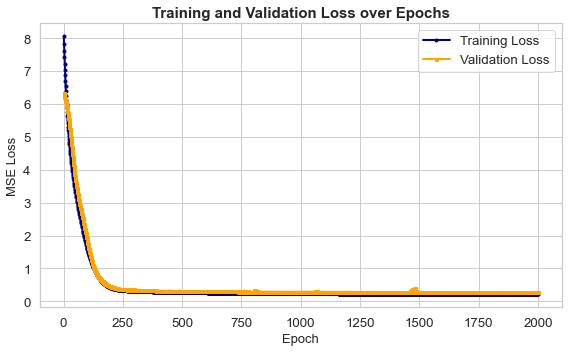

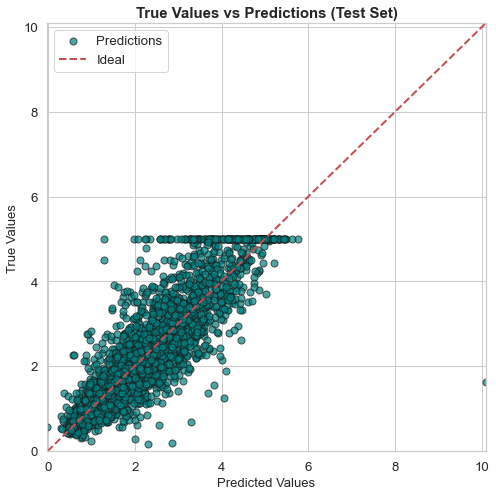

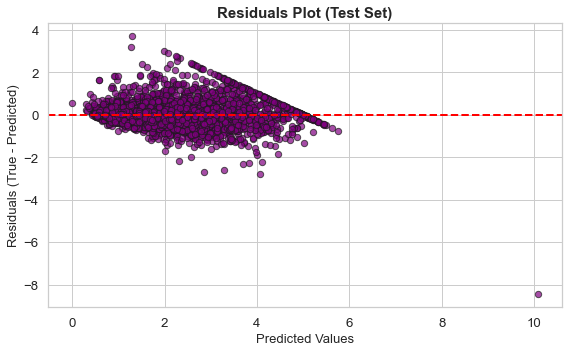

In [3]:
# 2. Define the feedforward neural network with BatchNorm layers
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim):
        super(FeedforwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            # Output layer is a single neuron for regression
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = FeedforwardNN(input_dim)

# 3. Set up loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training loop with loss tracking (evaluate both train and val losses, save best model)
# Increase it until you see overfitting
epochs = 2000
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None
best_epoch = -1

for epoch in range(epochs):
    # Training step
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)
    train_loss.backward()
    optimizer.step()
    train_losses.append(train_loss.item())

    # Validation step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

    # Save best model based on validation loss
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()
        best_epoch = epoch

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# After training, load the best model (based on validation loss)
model.load_state_dict(best_model_state)
print(f"Best model from epoch {best_epoch+1} with validation loss: {best_val_loss:.4f}")

# 5. Evaluation on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_loss = criterion(predictions, y_test_tensor)
    print(f"Test MSE: {test_loss.item():.4f}")

# --- Professional Figures for Performance ---

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Plot 1: Training and Validation Loss Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, color='navy', linewidth=2, marker='o', markersize=3, label='Training Loss')
plt.plot(range(1, epochs+1), val_losses, color='orange', linewidth=2, marker='s', markersize=3, label='Validation Loss')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('Training and Validation Loss over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot: True Values vs Predictions (Test Set)
y_true = y_test_tensor.cpu().numpy().flatten()
y_pred = predictions.cpu().numpy().flatten()

plt.figure(figsize=(7,7))
plt.scatter(y_pred, y_true, alpha=0.7, color='teal', edgecolors='k', s=50, label='Predictions')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.xlabel('Predicted Values', fontsize=13)
plt.ylabel('True Values', fontsize=13)
plt.title('True Values vs Predictions (Test Set)', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Residuals Plot
residuals = y_true - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.7, color='purple', edgecolors='k', s=40)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=13)
plt.ylabel('Residuals (True - Predicted)', fontsize=13)
plt.title('Residuals Plot (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1.2 Mini-Batch Training with Learning Rate Annealing and Z-Scored Gradients

In [4]:
# 2. Define the feedforward neural network with BatchNorm layers
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, num_layers=2, hidden_size=64):
        """
        input_dim: int, number of input features
        num_layers: int, number of hidden layers (>=1)
        hidden_size: int, number of neurons in each hidden layer
        """
        super(FeedforwardNN, self).__init__()
        layers = []
        in_dim = input_dim

        for i in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size

        # Output layer: single neuron for regression
        layers.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Mini-batch] Epoch 10/200, Train Loss: 1.0925, Val Loss: 1.6744, LR: 0.002000
[Mini-batch] Epoch 20/200, Train Loss: 0.3479, Val Loss: 0.4018, LR: 0.002000
[Mini-batch] Epoch 30/200, Train Loss: 0.3445, Val Loss: 0.4730, LR: 0.002000
[Mini-batch] Epoch 40/200, Train Loss: 0.2971, Val Loss: 0.3552, LR: 0.002000
[Mini-batch] Epoch 50/200, Train Loss: 0.2835, Val Loss: 0.3558, LR: 0.002000
[Mini-batch] Epoch 60/200, Train Loss: 0.2872, Val Loss: 0.3785, LR: 0.002000
[Mini-batch] Epoch 70/200, Train Loss: 0.2752, Val Loss: 0.4325, LR: 0.002000
[Mini-batch] Epoch 80/200, Train Loss: 0.2934, Val Loss: 0.3401, LR: 0.002000
[Mini-batch] Epoch 90/200, Train Loss: 0.2797, Val Loss: 0.3950, LR: 0.002000
[Mini-batch] Epoch 100/200, Train Loss: 0.2681, Val Loss: 0.3879, LR: 0.002000
[Mini-batch] Epoch 110/200, Train Loss: 0.2594, Val Loss: 0.3524, LR: 0.002000
[Mini-batch] Epoch 120/200, Train Loss: 0.2520, Val Loss: 0.3669, LR: 0.002000
[Mini-batch] Epoch 130/200, Train Loss: 0.2552, Val Loss: 0.3

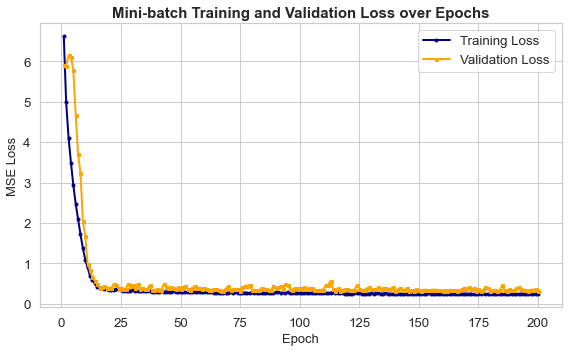

In [5]:
# Mini-batch training example with learning rate annealing

import torch
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDatasets for train and validation sets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Set batch size
batch_size = 4000

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Re-initialize model, optimizer, and loss for mini-batch training
model_mb = FeedforwardNN(input_dim, num_layers=3, hidden_size=64)
optimizer_mb = optim.Adam(model_mb.parameters(), lr=0.002)
criterion_mb = nn.MSELoss()

# Learning rate annealing: ReduceLROnPlateau
scheduler_mb = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mb, mode='min', factor=0.5, patience=50, verbose=True, min_lr=1e-4
)

epochs_mb = 200
train_losses_mb = []
val_losses_mb = []
best_val_loss_mb = float('inf')
best_model_state_mb = None
best_epoch_mb = -1

for epoch in range(epochs_mb):
    # Training step
    model_mb.train()
    running_train_loss = 0.0
    for xb, yb in train_loader:
        optimizer_mb.zero_grad()
        outputs = model_mb(xb)
        loss = criterion_mb(outputs, yb)
        loss.backward()

        # Z-score the gradients before optimizer step
        for param in model_mb.parameters():
            if param.grad is not None:
                grad = param.grad
                grad_mean = grad.mean()
                grad_std = grad.std(unbiased=False)
                # Avoid division by zero
                if grad_std > 0:
                    param.grad = (grad - grad_mean) / grad_std
                else:
                    param.grad = grad - grad_mean

        optimizer_mb.step()
        running_train_loss += loss.item() * xb.size(0)
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses_mb.append(epoch_train_loss)

    # Validation step
    model_mb.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model_mb(xb)
            loss = criterion_mb(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses_mb.append(epoch_val_loss)

    # Step the scheduler with validation loss
    scheduler_mb.step(epoch_val_loss)

    # Save best model based on validation loss
    if epoch_val_loss < best_val_loss_mb:
        best_val_loss_mb = epoch_val_loss
        best_model_state_mb = model_mb.state_dict()
        best_epoch_mb = epoch

    if (epoch+1) % 10 == 0:
        current_lr = optimizer_mb.param_groups[0]['lr']
        print(f"[Mini-batch] Epoch {epoch+1}/{epochs_mb}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, LR: {current_lr:.6f}")

# After training, load the best model (based on validation loss)
model_mb.load_state_dict(best_model_state_mb)
print(f"[Mini-batch] Best model from epoch {best_epoch_mb+1} with validation loss: {best_val_loss_mb:.4f}")

# Evaluate on test set
model_mb.eval()
with torch.no_grad():
    predictions_mb = model_mb(X_test_tensor)
    test_loss_mb = criterion_mb(predictions_mb, y_test_tensor)
    print(f"[Mini-batch] Test MSE: {test_loss_mb.item():.4f}")

# Plot: Training and Validation Loss Curve for Mini-batch Training
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs_mb+1), train_losses_mb, color='navy', linewidth=2, marker='o', markersize=3, label='Training Loss')
plt.plot(range(1, epochs_mb+1), val_losses_mb, color='orange', linewidth=2, marker='s', markersize=3, label='Validation Loss')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('Mini-batch Training and Validation Loss over Epochs', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
